In [1]:
# ==========================================
# 1. IMPORT LIBRARY
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
import tensorflow as tf
from prophet import Prophet
import warnings

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

In [2]:
# ==========================================
# 2. MOUNT GOOGLE DRIVE & BACA DATA (FIXED BOM & CURRENCY)
# ==========================================
from google.colab import drive
import pandas as pd
import os

print("Menghubungkan ke Google Drive...")
drive.mount('/content/drive')

# SESUAIKAN: Ganti path ini dengan lokasi file Anda di Drive
file_path = '/content/drive/MyDrive/Colab Notebooks/Coffe_sales.csv'

if os.path.exists(file_path):
    try:
        # 1. Gunakan encoding='utf-8-sig' untuk menghilangkan karakter \ufeff (BOM)
        # 2. Gunakan sep=None agar pandas mendeteksi sendiri pemisah (koma atau titik koma)
        df = pd.read_csv(file_path, sep=None, engine='python', encoding='utf-8-sig', on_bad_lines='skip')
        
        # Membersihkan spasi pada nama kolom
        df.columns = df.columns.str.strip()
        print("Daftar kolom ditemukan:", df.columns.tolist())

        # --- PREPROCESSING KOLOM DATE ---
        if 'date' in df.columns:
            # Menggunakan dayfirst=True karena format data Anda kemungkinan besar DD/MM/YYYY
            df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
            df = df.dropna(subset=['date'])
            print("Berhasil memproses kolom 'date'.")
        else:
            print("KOLOM 'date' TIDAK DITEMUKAN. Periksa kembali nama kolom!")

        # --- PREPROCESSING KOLOM MONEY (MEMBERSIHKAN FORMAT R38,70) ---
        if 'money' in df.columns:
            # Hapus huruf 'R', ganti koma ',' jadi titik '.', lalu ubah jadi angka (float)
            df['money'] = df['money'].replace({'R': '', ',': '.'}, regex=True).astype(float)
            print("Berhasil membersihkan data 'money'.")
        else:
            print("KOLOM 'money' TIDAK DITEMUKAN!")

        # --- AGREGASI MINGGUAN ---
        # Mengelompokkan pendapatan per hari
        df_daily = df.groupby('date')['money'].sum().reset_index()
        df_daily.set_index('date', inplace=True)

        # Resample menjadi data Mingguan (W)
        y = df_daily['money'].resample('W').sum().fillna(0)

        # Split Data (80% Train, 20% Test)
        train_size = int(len(y) * 0.8)
        train, test = y.iloc[:train_size], y.iloc[train_size:]

        print(f"\nPROSES SELESAI!")
        print(f"Total Data Mingguan: {len(y)} minggu")
        print(f"Data Training      : {len(train)} minggu")
        print(f"Data Testing       : {len(test)} minggu")

    except Exception as e:
        print(f"Gagal membaca file: {e}")
else:
    print(f"ERROR: File tidak ditemukan di: {file_path}")

Mounted at /content/drive
Daftar kolom ditemukan: ['date', 'datetime', 'hour_of_day', 'cash_type', 'card', 'money', 'coffee_name', 'Time_of_Day', 'Weekday', 'Month_name', 'Weekdaysort', 'Monthsort']
Berhasil memproses kolom 'date'.
Berhasil membersihkan data 'money'.

PROSES SELESAI!
Total Data Mingguan: 56 minggu
Data Training      : 44 minggu
Data Testing       : 12 minggu


In [3]:
# ==========================================
# 3. FUNGSI METRIK EVALUASI
# ==========================================
def smape(y_true, y_pred):
    return np.mean(2.0 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100

def mase(y_true, y_pred, y_train):
    naive_error = np.mean(np.abs(np.diff(y_train)))
    return mean_absolute_error(y_true, y_pred) / naive_error if naive_error != 0 else np.nan

def evaluate_model(name, y_true, y_pred, y_train, aic='N/A', bic='N/A'):
    return {
        'Model': name,
        'MAE': round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'MAPE (%)': round(mean_absolute_percentage_error(y_true, y_pred) * 100, 2),
        'SMAPE (%)': round(smape(y_true, y_pred), 2),
        'MASE': round(mase(y_true, y_pred, y_train), 2),
        'R²': round(r2_score(y_true, y_pred), 2),
        'AIC': round(aic, 2) if isinstance(aic, (int, float)) else aic,
        'BIC': round(bic, 2) if isinstance(bic, (int, float)) else bic
    }

metrics_list = []
predictions = pd.DataFrame(index=test.index)
predictions['Aktual'] = test


In [4]:
# ==========================================
# 4. TRAINING & PREDIKSI MODEL (COFFEE SALES)
# ==========================================

# A. Holt-Winters
print("Melatih model Holt-Winters...")
# Coba model add dan mul season lalu pilih AIC lebih kecil
hw_options = [
    {'trend':'add', 'seasonal':'add', 'seasonal_periods':4},
    {'trend':'add', 'seasonal':'mul', 'seasonal_periods':4},
    {'trend':'add', 'seasonal':'add', 'seasonal_periods':13},
]
best_hw = None
best_aic = np.inf
for opt in hw_options:
    try:
        model = ExponentialSmoothing(train, trend=opt['trend'], seasonal=opt['seasonal'], seasonal_periods=opt['seasonal_periods'], initialization_method='estimated').fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_hw = model
            best_hw_opts = opt
    except Exception as exc:
        print('HW gagal', opt, exc)

if best_hw is None:
    raise RuntimeError('Gagal fit Holt-Winters')

predictions['Holt-Winters'] = best_hw.forecast(len(test))
metrics_list.append(evaluate_model('Holt-Winters', test, predictions['Holt-Winters'], train, best_hw.aic, best_hw.bic))
print('Holt-Winters terbaik', best_hw_opts)

# B. SARIMA (Auto-tuning)
print("Melatih model SARIMA...")
try:
    from pmdarima import auto_arima
    sarima_auto = auto_arima(train, seasonal=True, m=4, max_p=3, max_q=3, max_P=2, max_Q=2, trace=False, error_action='ignore', suppress_warnings=True, stepwise=True)
    print('SARIMA order', sarima_auto.order, 'seasonal_order', sarima_auto.seasonal_order)
    predictions['SARIMA'] = sarima_auto.predict(n_periods=len(test))
    metrics_list.append(evaluate_model('SARIMA', test, predictions['SARIMA'], train, sarima_auto.aic(), sarima_auto.bic()))
except ModuleNotFoundError:
    print('pmdarima tidak ditemukan. Melewati pelatihan SARIMA. Install dengan pip install pmdarima jika ingin menggunakan.')
except Exception as exc:
    print(f'Gagal melatih SARIMA: {exc}')

# C. Random Forest (dengan fitur lag, kalendar, rolling)
print("Melatih model Random Forest...")

def create_lag_features(series, lag=8):
    df_rf = series.to_frame(name='money')
    for i in range(1, lag + 1):
        df_rf[f'lag_{i}'] = df_rf['money'].shift(i)
    df_rf['rolling_mean_3'] = df_rf['money'].rolling(3).mean()
    df_rf['rolling_mean_6'] = df_rf['money'].rolling(6).mean()
    df_rf['rolling_std_6'] = df_rf['money'].rolling(6).std()
    df_rf['month'] = df_rf.index.month
    df_rf['week'] = df_rf.index.isocalendar().week
    df_rf['quarter'] = df_rf.index.quarter
    return df_rf.dropna()

full_y = pd.concat([train, test])
full_rf = create_lag_features(full_y, lag=8)
train_rf = full_rf.loc[train.index.intersection(full_rf.index)]
test_rf = full_rf.loc[test.index.intersection(full_rf.index)]

features = [c for c in full_rf.columns if c != 'money']
X_train_rf = train_rf[features]
y_train_rf = train_rf['money']
X_test_rf = test_rf[features]

rf_model = RandomForestRegressor(n_estimators=400, max_depth=12, min_samples_split=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train_rf, y_train_rf)
predictions['Random Forest'] = rf_model.predict(X_test_rf)
metrics_list.append(evaluate_model('Random Forest', test_rf['money'], predictions['Random Forest'], train))

# D. LSTM (Deep Learning)
print("Melatih model LSTM (Deep Learning)...")
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))

look_back = 8
X_train_lstm, y_train_lstm = [], []
for i in range(look_back, len(train_scaled)):
    X_train_lstm.append(train_scaled[i-look_back:i, 0])
    y_train_lstm.append(train_scaled[i, 0])
X_train_lstm, y_train_lstm = np.array(X_train_lstm), np.array(y_train_lstm)
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], X_train_lstm.shape[1], 1))

inputs = y[len(y) - len(test) - look_back:].values.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test_lstm = np.array([inputs[i-look_back:i, 0] for i in range(look_back, len(inputs))])
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

from tensorflow.keras.callbacks import EarlyStopping
lstm_model = Sequential([LSTM(64, return_sequences=True, input_shape=(look_back, 1)), Dropout(0.2), LSTM(32), Dropout(0.2), Dense(1)])
lstm_model.compile(loss='mean_squared_error', optimizer='adam')
callback = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=150, batch_size=8, verbose=0, callbacks=[callback])

lstm_pred_scaled = lstm_model.predict(X_test_lstm, verbose=0)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
predictions['LSTM'] = lstm_pred.flatten()
metrics_list.append(evaluate_model('LSTM', test, predictions['LSTM'], train))

# E. Prophet (Meta)
print("Melatih model Prophet...")
train_prophet = train.reset_index().rename(columns={'date':'ds','money':'y'})
prophet_model = Prophet(yearly_seasonality='auto', weekly_seasonality=True, daily_seasonality=False)
prophet_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
prophet_model.add_seasonality(name='quarterly', period=91.25,fourier_order=3)
prophet_model.fit(train_prophet)

future = prophet_model.make_future_dataframe(periods=len(test), freq='W')
forecast_prophet = prophet_model.predict(future)

predictions['Prophet'] = forecast_prophet.set_index('ds').reindex(test.index)['yhat'].values
metrics_list.append(evaluate_model('Prophet', test, predictions['Prophet'], train))

print("\n--- Seluruh Model Berhasil Dilatih! ---")

Melatih model Holt-Winters...
Holt-Winters terbaik {'trend': 'add', 'seasonal': 'mul', 'seasonal_periods': 4}
Melatih model SARIMA...
pmdarima tidak ditemukan. Melewati pelatihan SARIMA. Install dengan pip install pmdarima jika ingin menggunakan.
Melatih model Random Forest...
Melatih model LSTM (Deep Learning)...
Melatih model Prophet...


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.



--- Seluruh Model Berhasil Dilatih! ---



=== HASIL EVALUASI MODEL (COFFEE SALES) ===


,Model,MAE,RMSE,MAPE (%),SMAPE (%),MASE,R²,AIC,BIC
1,Random Forest,360.36,508.40,13.60,15.27,0.80,0.64,N/A,N/A
2,LSTM,708.08,799.73,29.06,29.76,1.57,0.12,N/A,N/A
0,Holt-Winters,905.55,1060.07,33.42,38.32,2.01,-0.55,566.59,580.86
3,Prophet,1419.62,1559.55,73.18,57.21,3.14,-2.36,N/A,N/A



🏆 Model terbaik: Random Forest (SMAPE 15.27%)


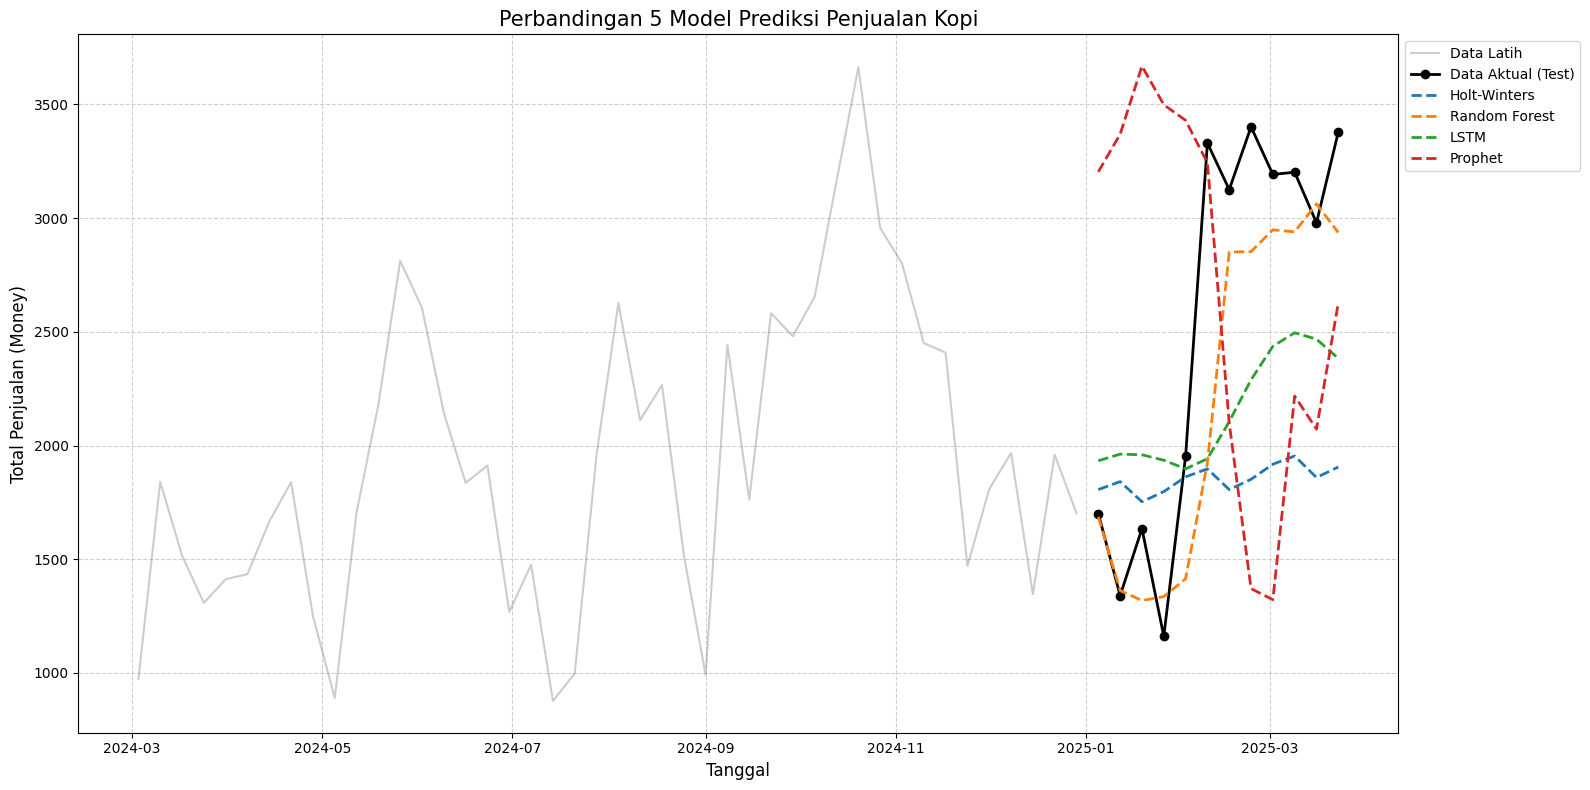

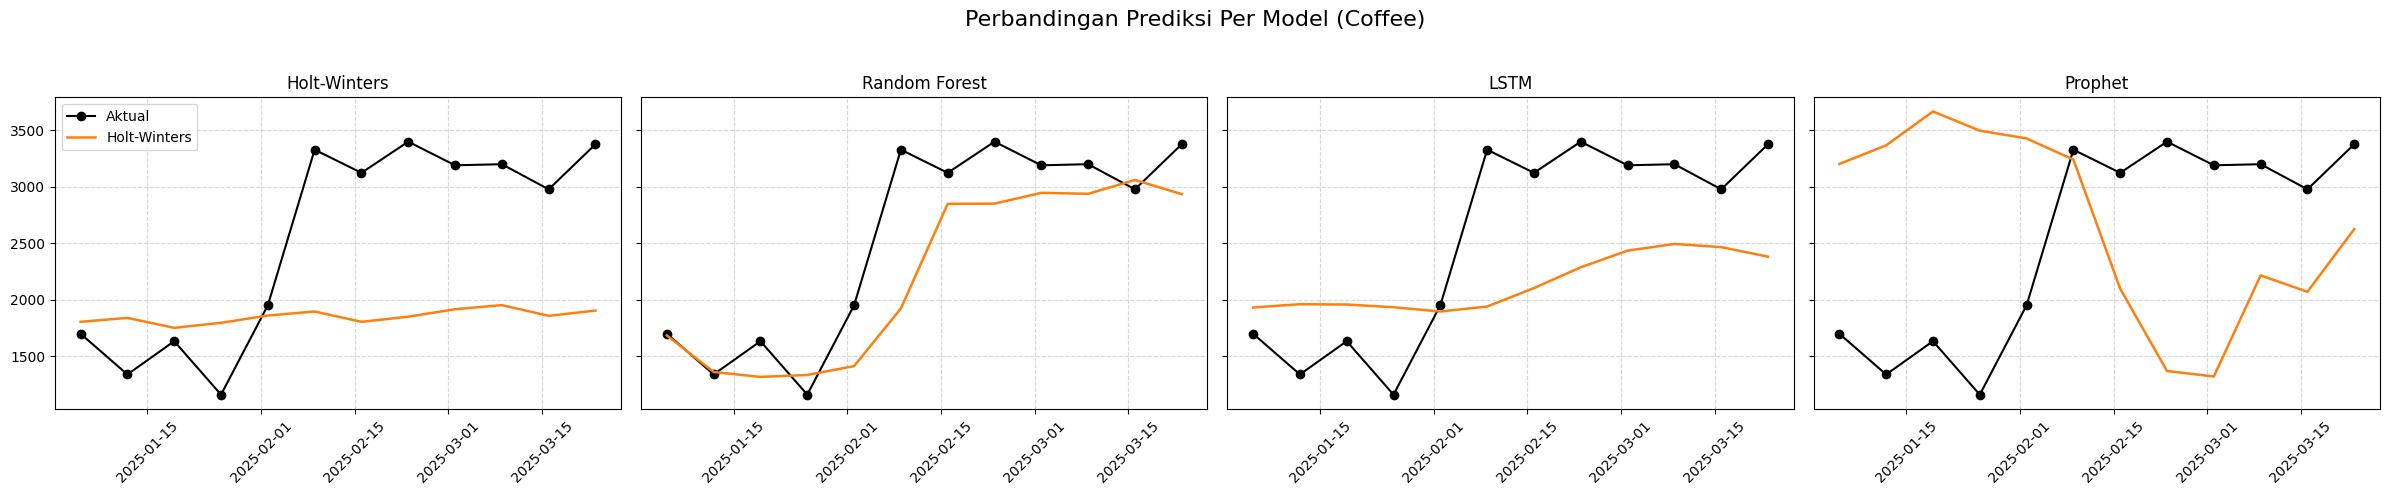


=== CONFUSION MATRIX TREN (NAIK/TURUN) ===


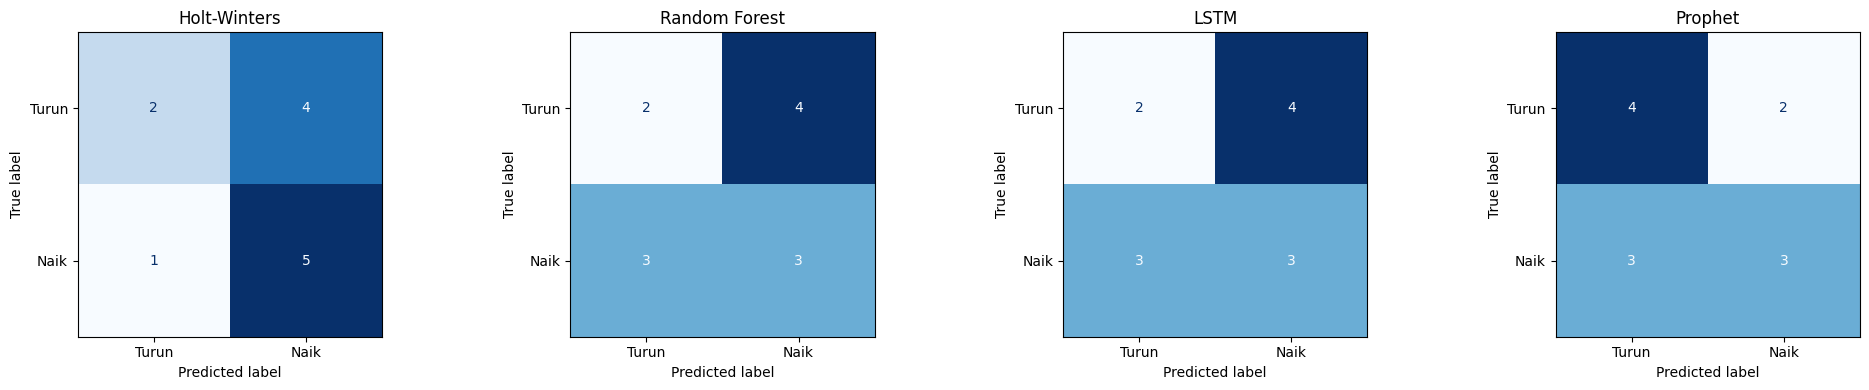

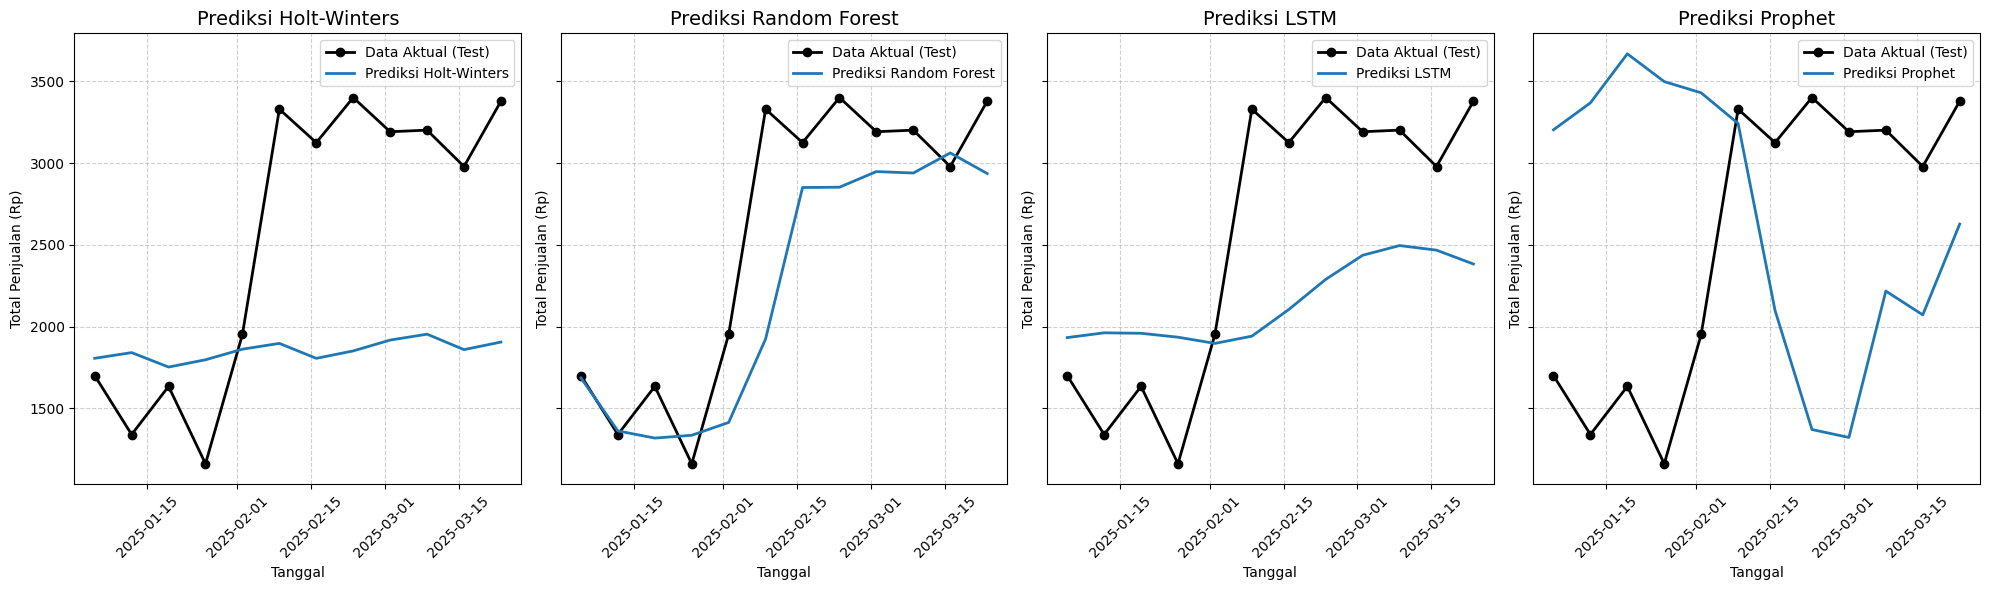


=== ANALISIS RESIDUAL (ERROR DISTRIBUTION) ===


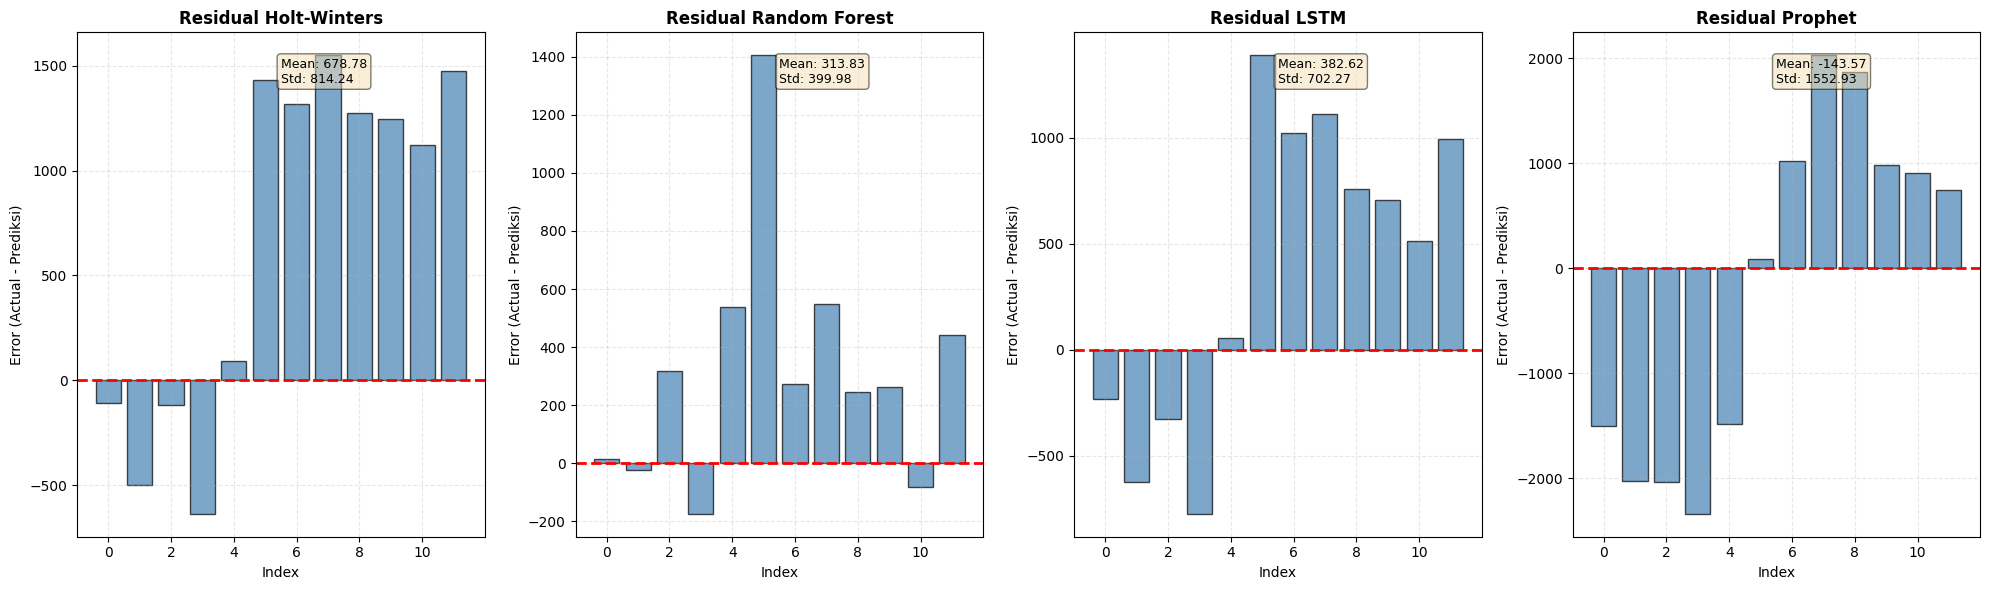


=== RANKING MODEL (SORTED BY SMAPE) ===
        Model  SMAPE (%)     MAE    RMSE    R²
Random Forest      15.27  360.36  508.40  0.64
         LSTM      29.76  708.08  799.73  0.12
 Holt-Winters      38.32  905.55 1060.07 -0.55
      Prophet      57.21 1419.62 1559.55 -2.36


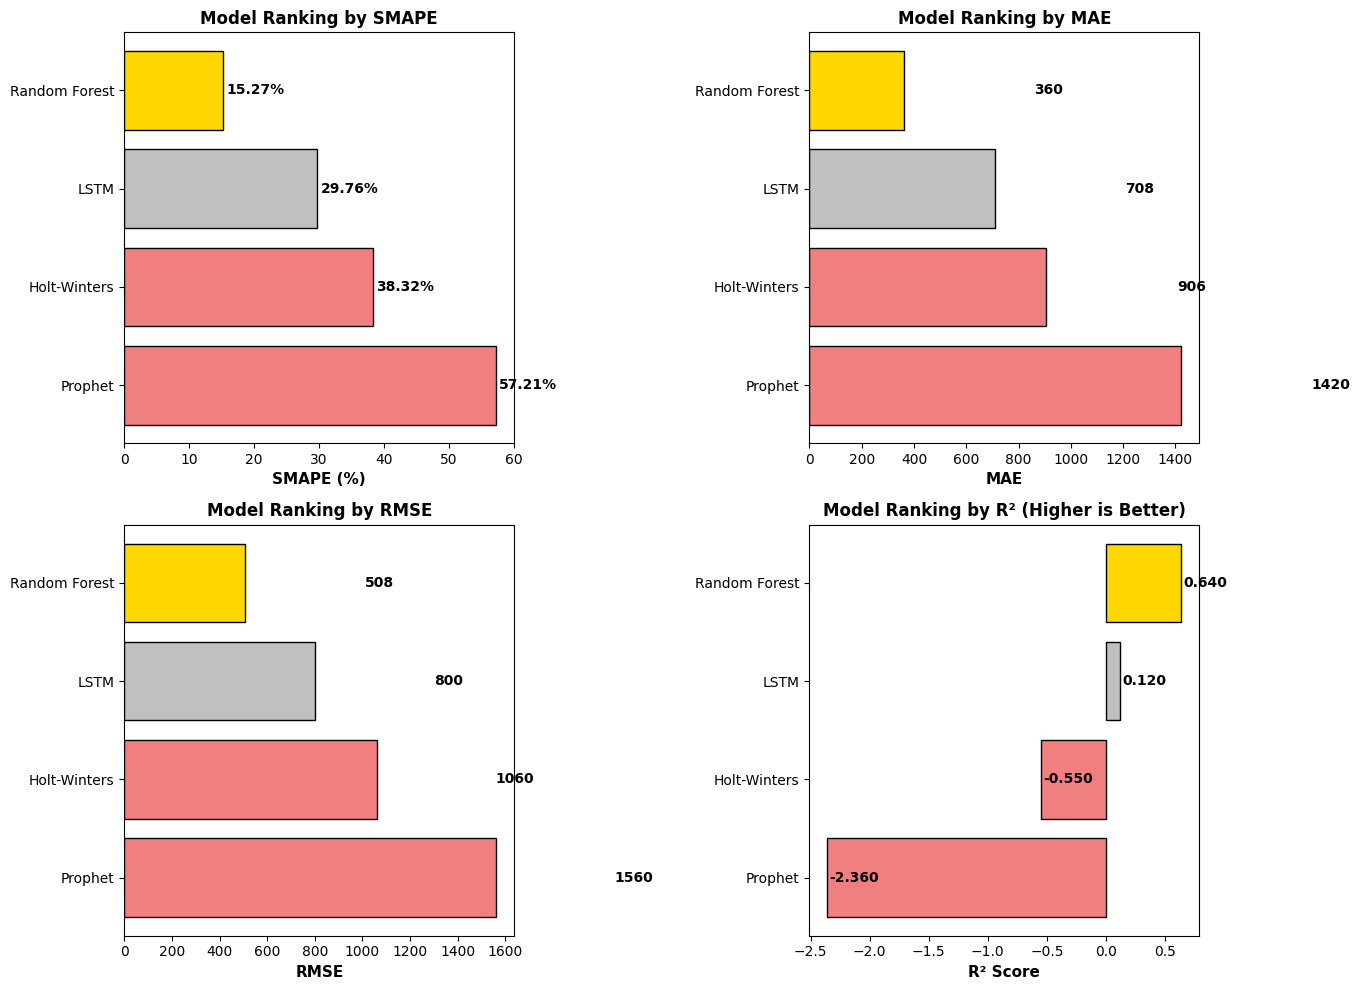

In [6]:
# ==========================================
# 5. HASIL & VISUALISASI
# ==========================================
df_metrics = pd.DataFrame(metrics_list)
df_metrics = df_metrics.sort_values(by='SMAPE (%)')
print("\n=== HASIL EVALUASI MODEL (COFFEE SALES) ===")
display(df_metrics)

# Model terbaik berdasarkan SMAPE
best_model = df_metrics.iloc[0]
print(f"\n🏆 Model terbaik: {best_model['Model']} (SMAPE {best_model['SMAPE (%)']:.2f}%)")

# Plot Perbandingan garis semua model
plt.figure(figsize=(16, 8))
plt.plot(train.index, train, label='Data Latih', color='grey', alpha=0.4)
plt.plot(test.index, test, label='Data Aktual (Test)', color='black', marker='o', linewidth=2)

for model in ['Holt-Winters', 'SARIMA', 'Random Forest', 'LSTM', 'Prophet']:
    if model in predictions.columns:
        plt.plot(test.index, predictions[model], label=model, linestyle='--', linewidth=2)

plt.title('Perbandingan 5 Model Prediksi Penjualan Kopi', fontsize=15)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Total Penjualan (Money)', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Perbandingan per model
models_to_plot = [m for m in ['Holt-Winters', 'SARIMA', 'Random Forest', 'LSTM', 'Prophet'] if m in predictions.columns]
fig, axes = plt.subplots(1, len(models_to_plot), figsize=(24, 5), sharey=True)
if len(models_to_plot) == 1:
    axes = [axes]
for idx, model in enumerate(models_to_plot):
    axes[idx].plot(test.index, test, label='Aktual', color='black', marker='o', linewidth=1.5)
    axes[idx].plot(test.index, predictions[model], label=model, color='tab:orange', linewidth=1.8)
    axes[idx].set_title(model)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(True, linestyle='--', alpha=0.5)
    if idx == 0:
        axes[idx].legend()
plt.suptitle('Perbandingan Prediksi Per Model (Coffee)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Confusion Matrix Tren Naik/Turun
print("\n=== CONFUSION MATRIX TREN (NAIK/TURUN) ===")
actual_trend = (test.values > np.append([train.iloc[-1]], test.values[:-1])).astype(int)
fig, axes = plt.subplots(1, len(models_to_plot), figsize=(5*len(models_to_plot), 4))
for idx, model in enumerate(models_to_plot):
    pred_trend = (predictions[model].values > np.append([train.iloc[-1]], predictions[model].values[:-1])).astype(int)
    cm = confusion_matrix(actual_trend, pred_trend)
    ConfusionMatrixDisplay(cm, display_labels=['Turun', 'Naik']).plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(model)
plt.tight_layout()
plt.show()

# ==========================================
# 6. GRAFIK PERBANDINGAN PREDIKSI (TERPISAH PER MODEL)
# ==========================================
models_to_plot = [m for m in ['Holt-Winters', 'SARIMA', 'Random Forest', 'LSTM', 'Prophet'] if m in predictions.columns]
fig, axes = plt.subplots(1, len(models_to_plot), figsize=(max(6, 5*len(models_to_plot)), 6), sharey=True)
if len(models_to_plot) == 1:
    axes = [axes]

for idx, model in enumerate(models_to_plot):
    axes[idx].plot(test.index, test, label='Data Aktual (Test)', color='black', marker='o', linewidth=2)
    axes[idx].plot(test.index, predictions[model], label=f'Prediksi {model}', linestyle='-', linewidth=2)
    axes[idx].set_title(f'Prediksi {model}', fontsize=14)
    axes[idx].set_xlabel('Tanggal', fontsize=10)
    axes[idx].set_ylabel('Total Penjualan (Rp)', fontsize=10)
    axes[idx].legend()
    axes[idx].grid(True, linestyle='--', alpha=0.6)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ==========================================
# 6B. GRAFIK PERBANDINGAN RESIDUAL ERROR
# ==========================================
print("\n=== ANALISIS RESIDUAL (ERROR DISTRIBUTION) ===")
models_to_plot = [m for m in ['Holt-Winters', 'SARIMA', 'Random Forest', 'LSTM', 'Prophet'] if m in predictions.columns]
fig, axes = plt.subplots(1, len(models_to_plot), figsize=(max(6, 5*len(models_to_plot)), 6))
if len(models_to_plot) == 1:
    axes = [axes]

for idx, model in enumerate(models_to_plot):
    residuals = test.values - predictions[model].values
    axes[idx].bar(range(len(residuals)), residuals, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[idx].set_title(f'Residual {model}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Index', fontsize=10)
    axes[idx].set_ylabel('Error (Actual - Prediksi)', fontsize=10)
    axes[idx].grid(True, linestyle='--', alpha=0.3)
    
    # Tambahkan statistik
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)
    axes[idx].text(0.5, 0.95, f'Mean: {mean_residual:.2f}\nStd: {std_residual:.2f}', 
                   transform=axes[idx].transAxes, fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# ==========================================
# 6C. RANKING MODEL BERDASARKAN METRIK
# ==========================================
print("\n=== RANKING MODEL (SORTED BY SMAPE) ===")
ranking = df_metrics[['Model', 'SMAPE (%)', 'MAE', 'RMSE', 'R²']].sort_values('SMAPE (%)')
print(ranking.to_string(index=False))

# Visualisasi ranking
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SMAPE Ranking
ax1 = axes[0, 0]
smape_sorted = df_metrics.sort_values('SMAPE (%)')
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(smape_sorted))]
ax1.barh(range(len(smape_sorted)), smape_sorted['SMAPE (%)'], color=colors, edgecolor='black')
ax1.set_yticks(range(len(smape_sorted)))
ax1.set_yticklabels(smape_sorted['Model'])
ax1.set_xlabel('SMAPE (%)', fontsize=11, fontweight='bold')
ax1.set_title('Model Ranking by SMAPE', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(smape_sorted['SMAPE (%)']):
    ax1.text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold')

# MAE Ranking
ax2 = axes[0, 1]
mae_sorted = df_metrics.sort_values('MAE')
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(mae_sorted))]
ax2.barh(range(len(mae_sorted)), mae_sorted['MAE'], color=colors, edgecolor='black')
ax2.set_yticks(range(len(mae_sorted)))
ax2.set_yticklabels(mae_sorted['Model'])
ax2.set_xlabel('MAE', fontsize=11, fontweight='bold')
ax2.set_title('Model Ranking by MAE', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
for i, v in enumerate(mae_sorted['MAE']):
    ax2.text(v + 500, i, f'{v:.0f}', va='center', fontweight='bold')

# RMSE Ranking
ax3 = axes[1, 0]
rmse_sorted = df_metrics.sort_values('RMSE')
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(rmse_sorted))]
ax3.barh(range(len(rmse_sorted)), rmse_sorted['RMSE'], color=colors, edgecolor='black')
ax3.set_yticks(range(len(rmse_sorted)))
ax3.set_yticklabels(rmse_sorted['Model'])
ax3.set_xlabel('RMSE', fontsize=11, fontweight='bold')
ax3.set_title('Model Ranking by RMSE', fontsize=12, fontweight='bold')
ax3.invert_yaxis()
for i, v in enumerate(rmse_sorted['RMSE']):
    ax3.text(v + 500, i, f'{v:.0f}', va='center', fontweight='bold')

# R² Ranking
ax4 = axes[1, 1]
r2_sorted = df_metrics.sort_values('R²', ascending=False)
colors = ['gold' if i == 0 else 'silver' if i == 1 else 'lightcoral' for i in range(len(r2_sorted))]
ax4.barh(range(len(r2_sorted)), r2_sorted['R²'], color=colors, edgecolor='black')
ax4.set_yticks(range(len(r2_sorted)))
ax4.set_yticklabels(r2_sorted['Model'])
ax4.set_xlabel('R² Score', fontsize=11, fontweight='bold')
ax4.set_title('Model Ranking by R² (Higher is Better)', fontsize=12, fontweight='bold')
ax4.invert_yaxis()
for i, v in enumerate(r2_sorted['R²']):
    ax4.text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()